# Normalization

Normalization is a scaling technique used to transform numerical data into a specific, restricted range—most commonly 0 to 1 or -1 to 1.

## When to Use Normalization
- Unknown Distribution: When you don’t know if your data follows a normal (bell curve) distribution.

- Distance-Based Models: Essential for algorithms like K-Nearest Neighbors (KNN) or K-Means Clustering, where the "distance" between points is used to make decisions.

- Image Processing: Pixels are often normalized from their original range (0–255) to 0–1 to help neural networks learn more efficiently.

## Key Types of Normalization1.

### 1. Min-Max Scaling
- The most popular type. It scales every value to fit between a set minimum and maximum (usually 0 and 1).

- Formula: $x_{norm} = \frac{x - min(x)}{max(x) - min(x)}$

- Weakness: Highly sensitive to outliers.7 If you have one massive value, all other values will be squashed into a tiny range near zero.

### 2. Mean Normalization:
Similar to Min-Max, but it centers the data around the mean so that the resulting values are usually between -1 and 1.
- Formula: $x_{norm} = \frac{x - mean(x)}{max(x) - min(x)}$

### 3. Max Abs Scaling
- It scales each feature by its maximum absolute value.This is particularly useful for data that is sparse (lots of zeros), as it preserves the zeros.
- Formula: $x_{norm} = \frac{x}{|max(x)|}$
- Result: All values fall between -1 and 1.

### 4. Decimal Scaling

This technique moves the decimal point of the values.10 The number of places moved depends on the maximum absolute value in the dataset.
- Example: If the max value is 999, we divide everything by 1,000 (moving the decimal 3 places).

- Formula: $x_{norm} = \frac{x}{10^j}$ (where 13$j$ is the number of digits in the max value)

1. Min-Max Scaling

This is the most common form of normalization. It reshapes the data into a fixed range, usually 0 to 1.

When to use: When you need a bounded range and your algorithm does not assume a specific distribution (e.g., Neural Networks using Sigmoid/Tanh activation or Image Processing).

When NOT to use: When your data has significant outliers, as they will compress all the "normal" data into a tiny, indistinguishable range.

Advantages:

Maintains the original distribution shape.

Ensures all features have the exact same boundaries.

Disadvantages:

Highly sensitive to outliers.

If new data comes in with values outside the original min/max, you have to rescale everything.

2. Mean Normalization

This technique centers the data at zero by subtracting the mean, then scales it by the range.

When to use: When you want your data to be centered around zero but still want it bounded within a specific range (typically -1 to 1).

When NOT to use: Similar to Min-Max, avoid this if you have extreme outliers that will skew the mean and range calculation.

Advantages: * Zero-centered data can help optimization algorithms (like Gradient Descent) converge faster.

Disadvantages: * Not a standard feature in scikit-learn (requires manual calculation).

Still very sensitive to outliers.

Max Abs Scaling

This scales each feature by its maximum absolute value, ensuring the range is -1 to 1.

When to use: Specifically designed for Sparse Data (data with many zeros, like text word counts or TF-IDF vectors).

When NOT to use: On dense data with a mean that is far from zero, as it doesn't center the data.

Advantages: * Preserves Sparsity: It does not shift the data (doesn't subtract a mean), so zeros remain zeros. This is crucial for memory efficiency in large datasets.

Disadvantages: * Extremely sensitive to a single large outlier, which becomes the "Max Abs" and squashes everything else.

4. Robust Scaling

This uses the Median and the Interquartile Range (IQR) rather than the Mean and Standard Deviation.

When to use: When your dataset contains outliers that you cannot remove. It is the "safest" scaler for dirty, real-world data.

When NOT to use: When your model requires a strictly bounded range (like 0 to 1) or when you've already handled outliers.

Advantages: * The median and IQR are not influenced by a few extreme values, so the "bulk" of your data remains well-scaled.

Disadvantages: * Does not produce a fixed range (like 0-1); outliers will still exist outside the main cluster.

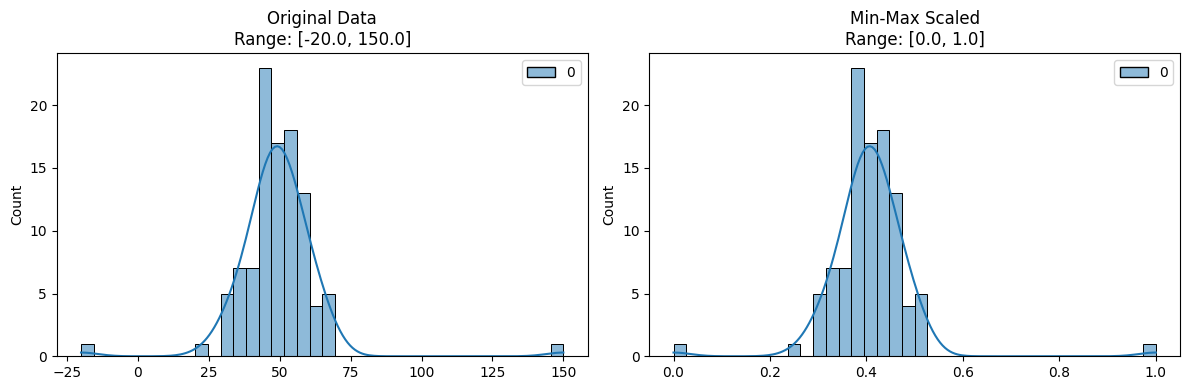

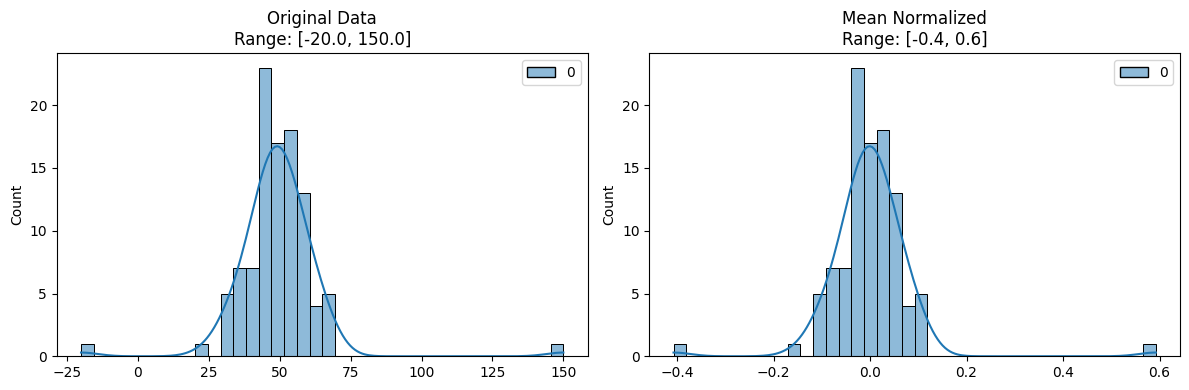

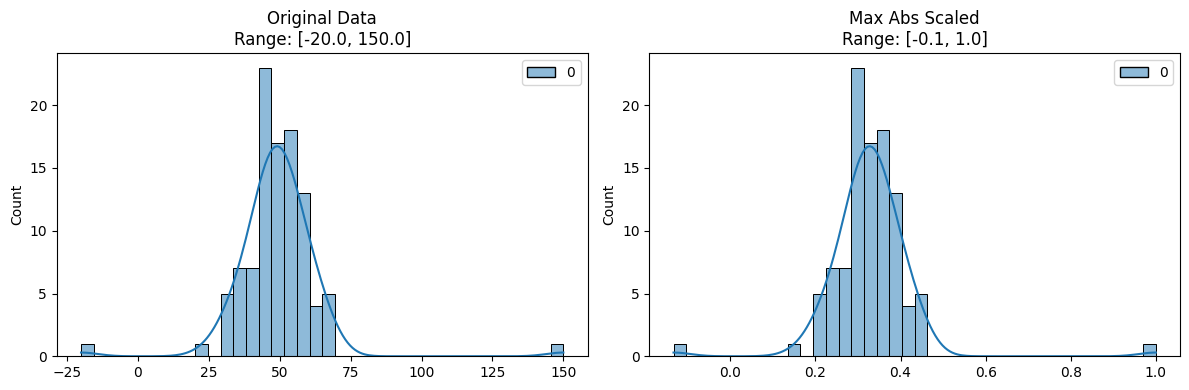

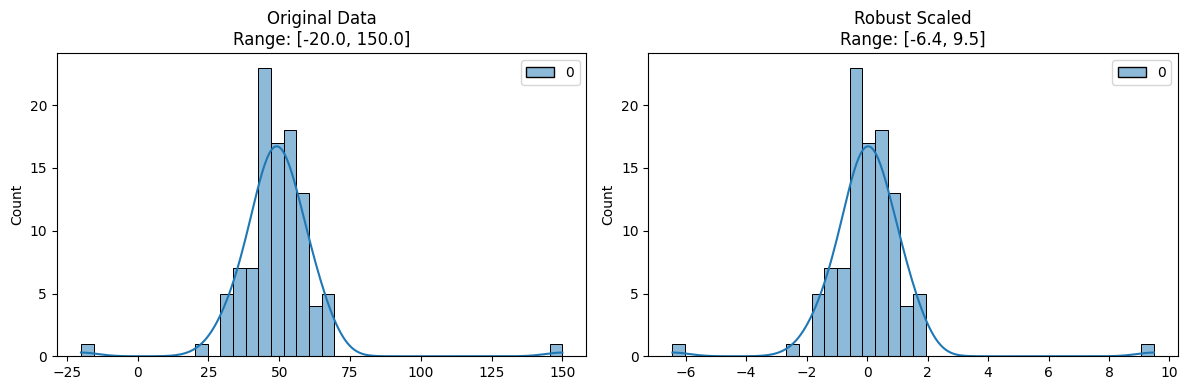

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler

# 1. Generate Synthetic Data with an Outlier
np.random.seed(42)
# Normal data (bulk of the dataset)
data = np.random.normal(loc=50, scale=10, size=100)
# Add extreme outliers
data = np.append(data, [150, -20]).reshape(-1, 1)

# 2. Apply the 4 Techniques
# Min-Max
min_max = MinMaxScaler().fit_transform(data)

# Mean Normalization (Manual)
mean_norm = (data - data.mean()) / (data.max() - data.min())

# Max Abs
max_abs = MaxAbsScaler().fit_transform(data)

# Robust Scaling
robust = RobustScaler().fit_transform(data)

# 3. Plotting Function
def plot_comparison(original, transformed, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Original
    sns.histplot(original, kde=True, ax=ax1, color='gray')
    ax1.set_title(f"Original Data\nRange: [{original.min():.1f}, {original.max():.1f}]")

    # Plot Transformed
    sns.histplot(transformed, kde=True, ax=ax2, color='teal')
    ax2.set_title(f"{title}\nRange: [{transformed.min():.1f}, {transformed.max():.1f}]")

    plt.tight_layout()
    plt.show()

# 4. Generate the Individual Graphs
plot_comparison(data, min_max, "Min-Max Scaled")
plot_comparison(data, mean_norm, "Mean Normalized")
plot_comparison(data, max_abs, "Max Abs Scaled")
plot_comparison(data, robust, "Robust Scaled")